## A4

Group members: Leckebusch Jens, ...

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

### Initialization

In [2]:
# Weibull parameters
weibull_params = {
    "rotor":     {"shape": 3, "scale": 3000},
    "bearing":   {"shape": 2, "scale": 3750},
    "gearbox":   {"shape": 3, "scale": 2400},
    "generator": {"shape": 2, "scale": 3300}
}

# Costs
C_fixed = 50   # per maintenance cycle (example)
C_access = 10  # turbine-to-turbine cost

# Replacement costs
C1 = {"rotor": 112, "bearing": 60, "gearbox": 152, "generator": 100}
C2 = {"rotor": 28,  "bearing": 15, "gearbox": 38,  "generator": 25}

# Age reduction
AGE_REDUCTION = {
    "minor": 0.30,
    "major": 0.50
}

# Condition-based thresholds (for CBM)
max_age = 0.95
min_age = 0.50

# Turbines
N_turbines = 50
COMPONENTS = ["rotor", "bearing", "gearbox", "generator"]

# N of Monte Carlo iterations (min 500)
ITER = 1000

# Seed
np.random.seed(42)

# Number of cycles to simulate
N_cycles = 10

In [3]:
# sample failure age (similar to matlab wblrnd)
def sample_failure_age(component):
    shape = weibull_params[component]["shape"]
    scale = weibull_params[component]["scale"]
    return np.random.weibull(shape) * scale

# create windfarm
def init_windfarm():
    """
    Initialize 50 turbines × 4 components.
    """
    farm = []
    for _ in range(N_turbines):
        turbine = {}
        for comp in COMPONENTS:
            turbine[comp] = {
                "virtual_age": 0.0,
                "failure_age": sample_failure_age(comp)
            }
        farm.append(turbine)
    return farm

### Plot functions

In [4]:
def plot_amc_stabilization(all_AMC, strategy_name, title="AMC Stabilization Curve", figsize=(7,4)):
    # running avg
    running_avg_amc = np.cumsum(all_AMC) / np.arange(1, len(all_AMC) + 1)
    # total avg
    final_avg = np.mean(all_AMC)

    plt.figure(figsize=figsize)
    plt.plot(running_avg_amc, lw=1.8, label="Running average AMC")
    plt.axhline(final_avg, color='r', linestyle='--', linewidth=1.5,
                label=f"Final average AMC = {final_avg:.2f}")
    plt.title(title)
    plt.xlabel("Monte Carlo iteration")
    plt.ylabel("Average AMC (EUR K/year)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_amc_" + strategy_name + ".png")
    plt.show()
    
def plot_coefficient_of_variation(all_AMC, strategy_name, title="Coefficient of Variation Convergence", figsize=(7,4)):
    """
    Plot the running coefficient of variation (CV) of AMC values to assess Monte Carlo convergence.
    CV = running standard deviation / running mean.
    """

    # running avg / mean
    running_mean = np.cumsum(all_AMC) / np.arange(1, len(all_AMC) + 1)

    # running var
    running_var = (np.cumsum((all_AMC - running_mean)**2)) / np.arange(1, len(all_AMC) + 1)
    running_std = np.sqrt(running_var)

    # running coefficient of variation
    running_cv = running_std / running_mean

    plt.figure(figsize=figsize)
    plt.plot(running_cv, lw=1.8, label="Running CV")
    plt.axhline(running_cv[-1], color='r', linestyle='--', linewidth=1.3,
                label=f"Final CV = {running_cv[-1]:.4f}")
    plt.title(title)
    plt.xlabel("Monte Carlo iteration")
    plt.ylabel("Coefficient of Variation")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_ac_" + strategy_name + ".png")
    plt.show()

### Analysis functions

In [5]:
def run_simple_montecarlo(strategy_function):
    #initialize
    all_AMC = []
    all_total_cost = []
    all_total_days = []
    all_fail_counts = []
    
    #montecarlo
    for _ in range(ITER):
        total_cost_10, total_days_10, AMC_10, failure_counts = strategy_function()
        all_total_cost.append(total_cost_10)
        all_total_days.append(total_days_10)
        all_AMC.append(AMC_10)
        all_fail_counts.append(failure_counts)
        
    #aggregate
    avg_AMC = float(np.mean(all_AMC))
    std_AMC = float(np.std(all_AMC, ddof=1))
    avg_total_cost = float(np.mean(all_total_cost))
    avg_total_days = float(np.mean(all_total_days))

    avg_failures = {
        comp: float(np.mean([fc[comp] for fc in all_fail_counts]))
        for comp in COMPONENTS
    }

    return all_AMC, avg_AMC, std_AMC, avg_total_cost, avg_total_days, avg_failures

### Assignment

#### Strategy 1

In [6]:
# Strategy 1 - implementation
def simulate_S1():
    
    #initialize
    farm = init_windfarm()
    total_cost = 0.0
    total_days = 0.0
    failure_counts = {c: 0 for c in COMPONENTS}
    
    # Run cycles
    for c in range(N_cycles):
        min_residual = np.inf
        failed_turbine_idx = None
        failed_component = None
        
        for ti in range(N_turbines):
            for comp in COMPONENTS:
                comp_state = farm[ti][comp]
                residual = comp_state["failure_age"] - comp_state["virtual_age"]
                if residual < min_residual:
                    min_residual = residual
                    failed_turbine_idx = ti
                    failed_component = comp
        
        #find time to next component failure
        dt = max(min_residual, 0.0)
        total_days += dt
            
        for ti in range(N_turbines):
            for comp in COMPONENTS:
                farm[ti][comp]["virtual_age"] += dt
                
        #costs # TODO: check if correct
        cycle_cost = C_fixed
        cycle_cost += C_access  # TODO: check if correct
        cycle_cost += C1[failed_component]  # corrective replacement

        total_cost += cycle_cost
        failure_counts[failed_component] += 1

        # replace component
        farm[failed_turbine_idx][failed_component]["virtual_age"] = 0.0
        farm[failed_turbine_idx][failed_component]["failure_age"] = sample_failure_age(failed_component)
        
        AMC = total_cost / total_days * 365.0
        
    return total_cost, total_days, AMC, failure_counts

  CORRECTIVE MAINTENANCE (CM) — EVENT-DRIVEN RESU   
Iterations: 1000, Cycles per iteration: 10, Turbines: 50
Average total cost over 10 cycles: 1636.35 EUR $
Average total elapsed days for 10 cycles: 875.3 days
Average AMC (per formula): 694.02 K EUR/year (std: 99.18)

Average number of failure replacements over 10 cycles (by component):
  rotor    : 1.269
  bearing  : 2.722
  gearbox  : 2.500
  generator: 3.509


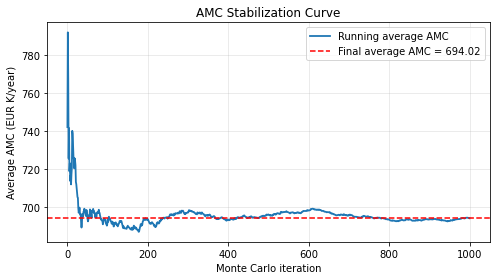

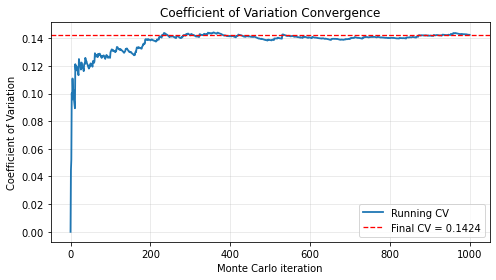

In [7]:
# Strategy 1 - execution
all_AMC, avg_AMC, std_AMC, avg_total_cost, avg_total_days, avg_failures = run_simple_montecarlo(simulate_S1)

print("============================================================")
print("  CORRECTIVE MAINTENANCE (CM) — EVENT-DRIVEN RESU   ")
print("============================================================")
print(f"Iterations: {ITER}, Cycles per iteration: {N_cycles}, Turbines: {N_turbines}")
print(f"Average total cost over 10 cycles: {avg_total_cost:.2f} EUR $")
print(f"Average total elapsed days for 10 cycles: {avg_total_days:.1f} days")
print(f"Average AMC (per formula): {avg_AMC:.2f} K EUR/year (std: {std_AMC:.2f})")
print("\nAverage number of failure replacements over 10 cycles (by component):")
for comp, val in avg_failures.items():
    print(f"  {comp:9s}: {val:.3f}")

plot_amc_stabilization(all_AMC, "s1", title="AMC Stabilization Curve", figsize=(7,4))
plot_coefficient_of_variation(all_AMC, "s1", title="Coefficient of Variation Convergence", figsize=(7,4))

#### Strategy 2

In [8]:
# Strategy 2

#### Strategy 3

In [9]:
# Strategy 3

#### Strategy 4

In [10]:
# Strategy 4

### Analysis